#CLASSIFICATION PROBLEM
import pandas as pd
from sklearn.model_selection import train_test_split


In [2]:
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

In [6]:
from sklearn.linear_model import LogisticRegression
import matplotlib.pyplot as plt

In [7]:
df=pd.read_csv("diabetes.csv")

In [8]:
df.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    int64  
 3   SkinThickness             768 non-null    int64  
 4   Insulin                   768 non-null    int64  
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB


In [10]:
df.isnull().sum()

Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    0
Age                         0
Outcome                     0
dtype: int64

In [14]:
df.shape

(768, 9)

In [13]:
df.columns

Index(['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness', 'Insulin',
       'BMI', 'DiabetesPedigreeFunction', 'Age', 'Outcome'],
      dtype='object')

In [49]:
x=df[['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI', 'DiabetesPedigreeFunction', 'Age']]  #dataframe
y=df["Outcome"]              #series



x_train, x_test,y_train,y_test=train_test_split(x,y,test_size=.20,random_state=42)

In [50]:
x_train

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age
60,2,84,0,0,0,0.0,0.304,21
618,9,112,82,24,0,28.2,1.282,50
346,1,139,46,19,83,28.7,0.654,22
294,0,161,50,0,0,21.9,0.254,65
231,6,134,80,37,370,46.2,0.238,46
...,...,...,...,...,...,...,...,...
71,5,139,64,35,140,28.6,0.411,26
106,1,96,122,0,0,22.4,0.207,27
270,10,101,86,37,0,45.6,1.136,38
435,0,141,0,0,0,42.4,0.205,29


In [51]:
lr=LogisticRegression(max_iter=1000)

In [52]:
lr.fit(x_train,y_train)

LogisticRegression(max_iter=1000)

In [53]:
y_pred=lr.predict(x_test)

In [54]:
x_pred=lr.predict(x_train)

In [55]:
acc=accuracy_score(y_test,y_pred)
acc

0.7467532467532467

In [56]:
conf_mat=confusion_matrix(y_test,y_pred)
conf_mat

array([[78, 21],
       [18, 37]])

In [58]:
clas_rpt= classification_report(y_test,y_pred)
clas_rpt

'              precision    recall  f1-score   support\n\n           0       0.81      0.79      0.80        99\n           1       0.64      0.67      0.65        55\n\n    accuracy                           0.75       154\n   macro avg       0.73      0.73      0.73       154\nweighted avg       0.75      0.75      0.75       154\n'

Text(0.5, 1.0, 'Confusion Matrix')

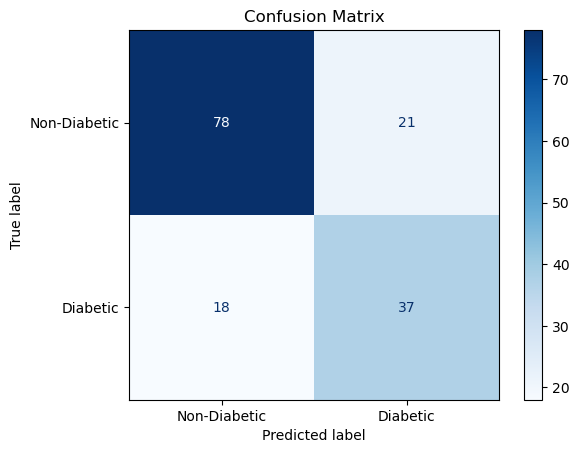

In [60]:
# Plot actual vs predicted values
from sklearn.metrics import ConfusionMatrixDisplay
disp=ConfusionMatrixDisplay(confusion_matrix=conf_mat,display_labels=["Non-Diabetic","Diabetic"])
disp.plot(cmap="Blues")
plt.title("Confusion Matrix")